<div style="line-height: 1.2; font-size: 0.9em;">

### 1. The Core Idea of Neural Networks
A neural network is essentially performing this task:
**Input $x$ → Linear Transformation $Wx + b$ → Non-linear Activation Function → Output Prediction**

The simplest single neuron:
$$z = w_1x_1 + w_2x_2 + b$$
$$a = f(z)$$

**Where:**
* **$x_1, x_2$:** Inputs
* **$w_1, w_2$:** Weights
* **$b$:** Bias
* **$f$:** Activation function
* **$a$:** Output

By stacking many neurons together, a **Neural Network** is formed.
</div>

<div style="line-height: 1.1; font-size: 0.85em; font-family: sans-serif;">

Here we use the **Sigmoid** activation function:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

It squashes any real number into the range between **0 and 1**, which can be interpreted as a "**probability**".

</div>

In [1]:
import numpy as np

# sigmoid 激活函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 一个神经元
def neuron(x, w, b):
    z = np.dot(x, w) + b
    a = sigmoid(z)
    return z, a

# 输入
x = np.array([2.0, 1.0])

# 权重
w = np.array([0.8, 0.5])

# 偏置
b = -1.0

z, a = neuron(x, w, b)

print("z =", z)
print("a =", a)
print("预测类别 =", 1 if a >= 0.5 else 0)

z = 1.1
a = 0.7502601055951177
预测类别 = 1


<div style="line-height: 1.1; font-size: 0.85em; font-family: sans-serif;">

### Explanation
First, calculate:
$$z = 2.0 \times 0.8 + 1.0 \times 0.5 - 1.0 = 1.1$$

Then, calculate:
$$a = \sigma(1.1) \approx 0.75$$

Since **0.75 is greater than 0.5**, the prediction is **1**.

</div>

<div style="line-height: 1.1; font-size: 0.85em; font-family: sans-serif;">

### Model Structure
This is still a single neuron:
$$\hat{y} = \sigma(w_1x_1 + w_2x_2 + b)$$

The loss function uses Mean Squared Error (MSE):
$$L = \frac{1}{n} \sum (\hat{y} - y)^2$$

Then, use Gradient Descent to update the parameters.

</div>

<div style="line-height: 1.1; font-size: 0.85em; font-family: sans-serif;">

Assume:
$$L = (\hat{y} - y)^2$$
$$\hat{y} = \sigma(z)$$
$$z = w_1x_1 + w_2x_2 + b$$

To find:
$$\frac{\partial L}{\partial w_1}$$

Using the **Chain Rule**:
$$\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w_1}$$

Where:
$$\frac{\partial L}{\partial \hat{y}} = 2(\hat{y} - y)$$
$$\frac{\partial \hat{y}}{\partial z} = \hat{y}(1 - \hat{y})$$
$$\frac{\partial z}{\partial w_1} = x_1$$

Therefore:
$$\frac{\partial L}{\partial w_1} = 2(\hat{y} - y)\hat{y}(1 - \hat{y})x_1$$

This explains how the "error is propagated back to the parameters."

</div>

## 训练单神经元

In [1]:
import numpy as np

# 1. 数据集：AND 逻辑
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([[0], [0], [0], [1]], dtype=float)

# 2. 激活函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

# 3. 初始化参数
np.random.seed(42)
W = np.random.randn(2, 1) * 0.1
b = np.zeros((1, 1))

# 4. 超参数
lr = 0.5 # learning rate
epochs = 5000

# 5. 训练
for epoch in range(epochs):
    # 前向传播
    z = X @ W + b           # shape: (4,1)
    y_hat = sigmoid(z)

    # 损失
    loss = np.mean((y_hat - y) ** 2)

    # 反向传播
    # dL/dy_hat
    dL_dyhat = 2 * (y_hat - y) / len(X)

    # dy_hat/dz
    dyhat_dz = sigmoid_derivative(y_hat)

    # dL/dz
    dL_dz = dL_dyhat * dyhat_dz

    # dL/dW 和 dL/db
    dW = X.T @ dL_dz
    db = np.sum(dL_dz, axis=0, keepdims=True)

    # 参数更新
    W -= lr * dW
    b -= lr * db

    if epoch % 500 == 0:
        print(f"epoch {epoch}, loss = {loss:.6f}")

# 6. 测试
print("\n训练完成后的预测：")
z = X @ W + b
y_hat = sigmoid(z)

for i in range(len(X)):
    print(f"输入 {X[i]} -> 预测值 {y_hat[i,0]:.4f} -> 类别 {1 if y_hat[i,0] >= 0.5 else 0}")

epoch 0, loss = 0.250061
epoch 500, loss = 0.025991
epoch 1000, loss = 0.012396
epoch 1500, loss = 0.007891
epoch 2000, loss = 0.005718
epoch 2500, loss = 0.004457
epoch 3000, loss = 0.003638
epoch 3500, loss = 0.003067
epoch 4000, loss = 0.002647
epoch 4500, loss = 0.002326

训练完成后的预测：
输入 [0. 0.] -> 预测值 0.0002 -> 类别 0
输入 [0. 1.] -> 预测值 0.0493 -> 类别 0
输入 [1. 0.] -> 预测值 0.0493 -> 类别 0
输入 [1. 1.] -> 预测值 0.9414 -> 类别 1


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# 1. XOR 数据
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)
y = np.array([[0], [1], [1], [0]], dtype=float)

Text(0, 0.5, 'X2')

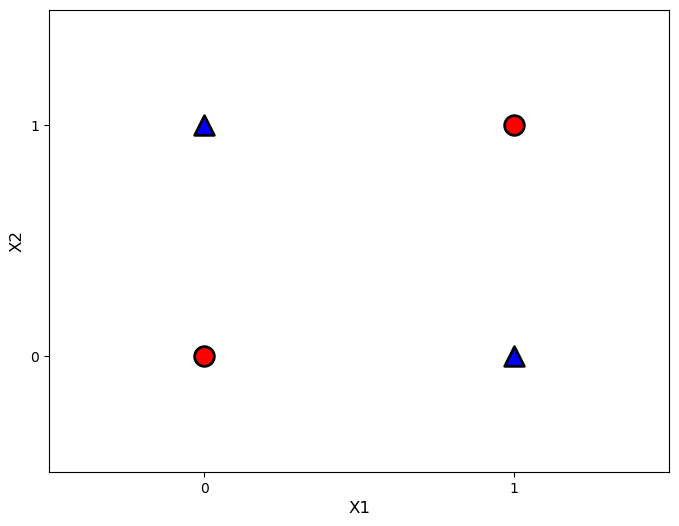

In [3]:
# 创建图形
plt.figure(figsize=(8, 6))

# 根据标签值设置不同颜色和标记
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i, 0], X[i, 1], color='red', s=200, marker='o', edgecolors='black', linewidth=2, label='Class 0' if i == 0 else '')
    else:
        plt.scatter(X[i, 0], X[i, 1], color='blue', s=200, marker='^', edgecolors='black', linewidth=2, label='Class 1' if i == 1 else '')

# 设置坐标轴
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)

In [4]:

# 2. 激活函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

# 3. 初始化参数
np.random.seed(42)
W1 = np.random.randn(2, 2) * 0.5
b1 = np.zeros((1, 2))

W2 = np.random.randn(2, 1) * 0.5
b2 = np.zeros((1, 1))

# 4. 超参数
lr = 1.0
epochs = 10000

# 5. 训练
for epoch in range(epochs):
    # ===== 前向传播 =====
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)

    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    # 损失
    loss = np.mean((A2 - y) ** 2)

    # ===== 反向传播 =====
    dA2 = 2 * (A2 - y) / len(X)
    dZ2 = dA2 * sigmoid_derivative(A2)

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * sigmoid_derivative(A1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # ===== 更新 =====
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    if epoch % 1000 == 0:
        print(f"epoch {epoch}, loss = {loss:.6f}")

# 6. 测试
print("\n训练完成后的预测：")
Z1 = X @ W1 + b1
A1 = sigmoid(Z1)
Z2 = A1 @ W2 + b2
A2 = sigmoid(Z2)

for i in range(len(X)):
    print(f"输入 {X[i]} -> 预测值 {A2[i,0]:.4f} -> 类别 {1 if A2[i,0] >= 0.5 else 0}")

epoch 0, loss = 0.251156
epoch 1000, loss = 0.249849
epoch 2000, loss = 0.151592
epoch 3000, loss = 0.128813
epoch 4000, loss = 0.126921
epoch 5000, loss = 0.126268
epoch 6000, loss = 0.125941
epoch 7000, loss = 0.125746
epoch 8000, loss = 0.125617
epoch 9000, loss = 0.125525

训练完成后的预测：
输入 [0. 0.] -> 预测值 0.0185 -> 类别 0
输入 [0. 1.] -> 预测值 0.4993 -> 类别 0
输入 [1. 0.] -> 预测值 0.9832 -> 类别 1
输入 [1. 1.] -> 预测值 0.5005 -> 类别 1
